In [8]:
import pandas as pd

# Load Houston employment data
employment = pd.read_csv("../data/raw/houston_employment.csv")

# Load oil prices data
oil = pd.read_csv("../data/raw/wti_oil_prices.csv")

# Load retail sales Excel file
retail = pd.read_excel("../data/raw/us_retail_sales.xlsx")

# Preview datasets
print("EMPLOYMENT DATA")
print(employment.head())

print("\nOIL PRICE DATA")
print(oil.head())

print("\nRETAIL SALES DATA")
print(retail.head())

EMPLOYMENT DATA
  observation_date  HOUS448NA
0       1990-01-01     1738.0
1       1990-02-01     1745.1
2       1990-03-01     1752.2
3       1990-04-01     1763.2
4       1990-05-01     1776.8

OIL PRICE DATA
  observation_date  DCOILWTICO
0       2021-05-04       65.72
1       2021-05-05       65.63
2       2021-05-06       64.73
3       2021-05-07       64.96
4       2021-05-10       64.92

RETAIL SALES DATA
  Table 1.  Estimated Monthly Sales for Retail and Food Services, by Kind of Business  \
0                                                NaN                                    
1                                                NaN                                    
2  (Total sales estimates are shown in millions o...                                    
3                       and administrative records.)                                    
4                                                NaN                                    

  Unnamed: 1    Unnamed: 2 Unnamed: 3 Unnamed: 4

In [9]:
# Dataset dimensions
print("EMPLOYMENT SHAPE:", employment.shape)
print("OIL SHAPE:", oil.shape)
print("RETAIL SHAPE:", retail.shape)

print("\nEMPLOYMENT COLUMNS")
print(employment.columns)

print("\nOIL COLUMNS")
print(oil.columns)

print("\nRETAIL COLUMNS")
print(retail.columns)

EMPLOYMENT SHAPE: (434, 2)
OIL SHAPE: (1305, 2)
RETAIL SHAPE: (86, 14)

EMPLOYMENT COLUMNS
Index(['observation_date', 'HOUS448NA'], dtype='str')

OIL COLUMNS
Index(['observation_date', 'DCOILWTICO'], dtype='str')

RETAIL COLUMNS
Index(['Table 1.  Estimated Monthly Sales for Retail and Food Services, by Kind of Business',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='str')


In [10]:
# Convert date columns to datetime format

employment['observation_date'] = pd.to_datetime(employment['observation_date'])

oil['observation_date'] = pd.to_datetime(oil['observation_date'])

# Check data types
print(employment.dtypes)

print("\n")

print(oil.dtypes)

observation_date    datetime64[us]
HOUS448NA                  float64
dtype: object


observation_date    datetime64[us]
DCOILWTICO                 float64
dtype: object


In [11]:
# Create month column for oil data

oil['month'] = oil['observation_date'].dt.to_period('M')

# Group by month and calculate average oil price

monthly_oil = oil.groupby('month')['DCOILWTICO'].mean().reset_index()

# Convert month back to datetime

monthly_oil['month'] = monthly_oil['month'].dt.to_timestamp()

# Preview cleaned monthly oil data

print(monthly_oil.head())

       month  DCOILWTICO
0 2021-05-01   65.206842
1 2021-06-01   71.378182
2 2021-07-01   72.485238
3 2021-08-01   67.730455
4 2021-09-01   71.646190


In [12]:
# Preview first 15 rows of retail data

retail.head(15)

,"Table 1. Estimated Monthly Sales for Retail and Food Services, by Kind of Business",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,(Total sales estimates are shown in millions o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,and administrative records.),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Not Adjusted,NaN,NaN,NaN,NaN,NaN,NaN,Adjusted2,NaN,NaN,NaN,NaN
5,NAICS1,Kind of Business,3 Month Total,NaN,2026,NaN,NaN,2025,NaN,2026,NaN,NaN,2025,NaN
6,code,NaN,NaN,% Chg.,Mar.3,Feb.,Jan.,Mar.,Feb.,Mar.3,Feb.,Jan.,Mar.,Feb.
7,NaN,NaN,2026,2025,(a),(p),(r),NaN,NaN,(a),(p),(r),(r),(r)
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,"Retail & food services,",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Create simplified retail sales table

retail_kpi = pd.DataFrame({
    'month': ['2025-02', '2025-03', '2026-01', '2026-02', '2026-03'],
    'adjusted_sales_millions': [711575, 723350, 734503, 739772, 752063]
})

# Convert month column to datetime

retail_kpi['month'] = pd.to_datetime(retail_kpi['month'])

# Preview dataset

print(retail_kpi)

       month  adjusted_sales_millions
0 2025-02-01                   711575
1 2025-03-01                   723350
2 2026-01-01                   734503
3 2026-02-01                   739772
4 2026-03-01                   752063


In [14]:
# Load clean retail sales data from FRED

retail = pd.read_csv("../data/raw/us_retail_sales.csv")

# Preview retail dataset

print(retail.head())

print("\n")

print(retail.dtypes)

  observation_date     RRSFS
0       2021-03-01  227800.0
1       2021-04-01  228405.0
2       2021-05-01  225529.0
3       2021-06-01  226100.0
4       2021-07-01  221335.0


observation_date        str
RRSFS               float64
dtype: object


In [15]:
# Convert retail date column to datetime

retail['observation_date'] = pd.to_datetime(retail['observation_date'])

# Rename columns to business-friendly names

retail = retail.rename(columns={
    'observation_date': 'month',
    'RRSFS': 'retail_sales'
})

# Preview cleaned retail dataset

print(retail.head())

print("\n")

print(retail.dtypes)

       month  retail_sales
0 2021-03-01      227800.0
1 2021-04-01      228405.0
2 2021-05-01      225529.0
3 2021-06-01      226100.0
4 2021-07-01      221335.0


month           datetime64[us]
retail_sales           float64
dtype: object


In [16]:
# Rename employment columns

employment = employment.rename(columns={
    'observation_date': 'month',
    'HOUS448NA': 'houston_employment'
})

# Rename oil column

monthly_oil = monthly_oil.rename(columns={
    'DCOILWTICO': 'avg_wti_oil_price'
})

# Preview datasets

print(employment.head())

print("\n")

print(monthly_oil.head())

       month  houston_employment
0 1990-01-01              1738.0
1 1990-02-01              1745.1
2 1990-03-01              1752.2
3 1990-04-01              1763.2
4 1990-05-01              1776.8


       month  avg_wti_oil_price
0 2021-05-01          65.206842
1 2021-06-01          71.378182
2 2021-07-01          72.485238
3 2021-08-01          67.730455
4 2021-09-01          71.646190


In [17]:
# Merge employment + oil datasets

merged_data = employment.merge(
    monthly_oil,
    on='month',
    how='inner'
)

# Merge retail sales data

merged_data = merged_data.merge(
    retail,
    on='month',
    how='inner'
)

# Preview final merged dataset

print(merged_data.head())

print("\n")

print(merged_data.shape)

       month  houston_employment  avg_wti_oil_price  retail_sales
0 2021-05-01              3034.6          65.206842      225529.0
1 2021-06-01              3046.4          71.378182      226100.0
2 2021-07-01              3091.2          72.485238      221335.0
3 2021-08-01              3096.1          67.730455      222071.0
4 2021-09-01              3107.9          71.646190      222581.0


(58, 4)


Matplotlib is building the font cache; this may take a moment.


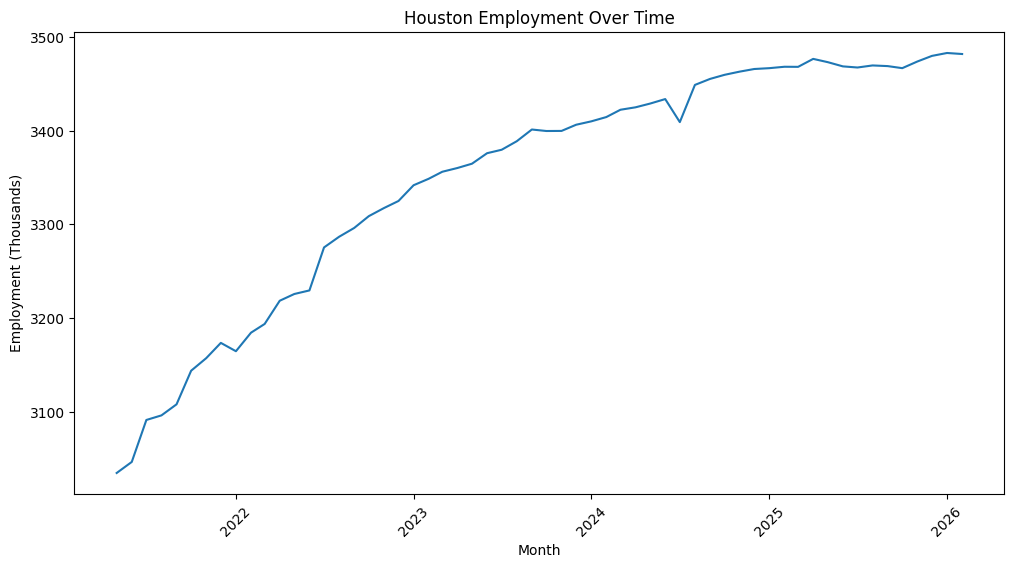

In [18]:
import matplotlib.pyplot as plt

# Create chart

plt.figure(figsize=(12,6))

plt.plot(
    merged_data['month'],
    merged_data['houston_employment']
)

# Labels

plt.title('Houston Employment Over Time')

plt.xlabel('Month')

plt.ylabel('Employment (Thousands)')

plt.xticks(rotation=45)

plt.show()

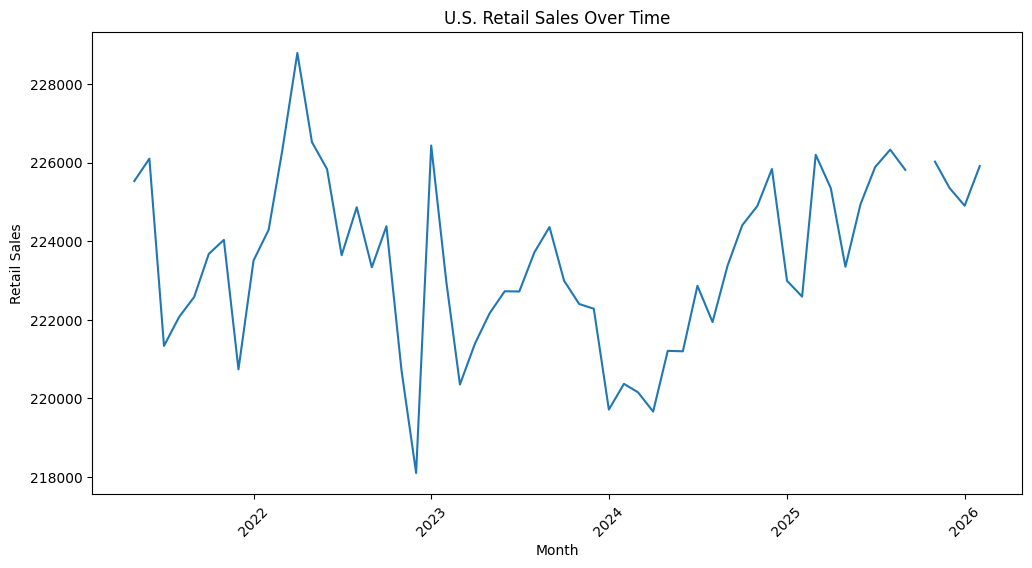

In [19]:
# Retail sales trend

plt.figure(figsize=(12,6))

plt.plot(
    merged_data['month'],
    merged_data['retail_sales']
)

plt.title('U.S. Retail Sales Over Time')

plt.xlabel('Month')

plt.ylabel('Retail Sales')

plt.xticks(rotation=45)

plt.show()

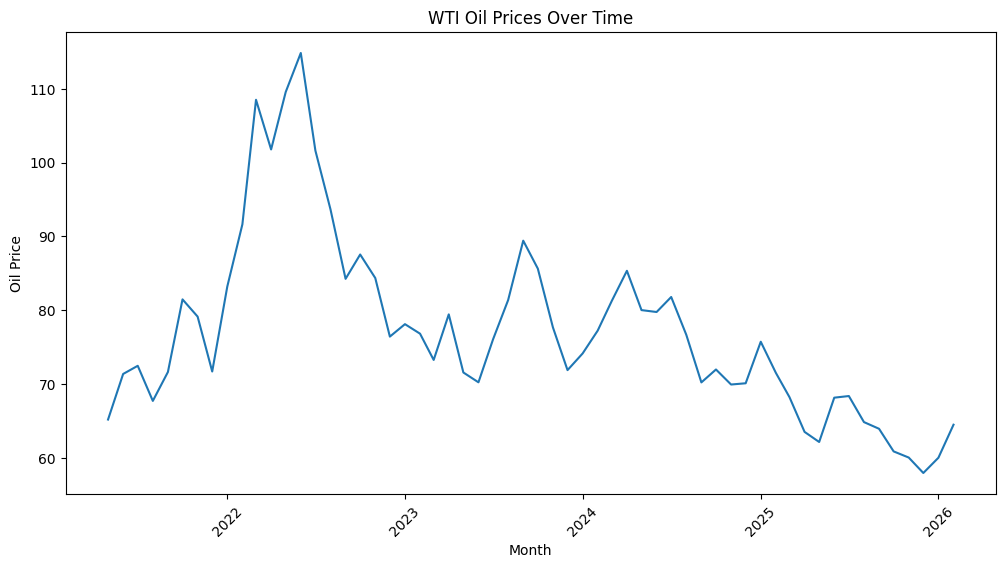

In [20]:
# Oil price trend

plt.figure(figsize=(12,6))

plt.plot(
    merged_data['month'],
    merged_data['avg_wti_oil_price']
)

plt.title('WTI Oil Prices Over Time')

plt.xlabel('Month')

plt.ylabel('Oil Price')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Correlation analysis

correlation_matrix = merged_data[
    ['houston_employment', 'avg_wti_oil_price', 'retail_sales']
].corr()

print(correlation_matrix)

                    houston_employment  avg_wti_oil_price  retail_sales
houston_employment            1.000000          -0.390048     -0.030824
avg_wti_oil_price            -0.390048           1.000000      0.081066
retail_sales                 -0.030824           0.081066      1.000000


In [ ]:
elation_matrix)

In [22]:
# Export merged analytical dataset

merged_data.to_csv(
    "../data/cleaned/houston_consumer_demand.csv",
    index=False
)

print("Clean dataset exported successfully.")

Clean dataset exported successfully.


In [23]:
import sqlite3

# Create/connect to SQLite database

conn = sqlite3.connect("../data/cleaned/houston_consumer_demand.db")

print("Database created successfully.")

Database created successfully.


In [24]:
merged_data.to_sql(
    'consumer_demand',
    conn,
    if_exists='replace',
    index=False
)

print("Table loaded successfully.")

Table loaded successfully.


In [25]:
# Simple SQL query

query = """
SELECT *
FROM consumer_demand
LIMIT 5
"""

# Run query

sql_preview = pd.read_sql_query(query, conn)

print(sql_preview)

                 month  houston_employment  avg_wti_oil_price  retail_sales
0  2021-05-01 00:00:00              3034.6          65.206842      225529.0
1  2021-06-01 00:00:00              3046.4          71.378182      226100.0
2  2021-07-01 00:00:00              3091.2          72.485238      221335.0
3  2021-08-01 00:00:00              3096.1          67.730455      222071.0
4  2021-09-01 00:00:00              3107.9          71.646190      222581.0


In [26]:
# KPI summary query

query = """
SELECT
    AVG(houston_employment) AS avg_employment,
    AVG(avg_wti_oil_price) AS avg_oil_price,
    AVG(retail_sales) AS avg_retail_sales
FROM consumer_demand
"""

# Run query

kpi_summary = pd.read_sql_query(query, conn)

print(kpi_summary)

   avg_employment  avg_oil_price  avg_retail_sales
0     3349.148276      77.215507     223546.403509


In [27]:
# Highest oil price months

query = """
SELECT
    month,
    avg_wti_oil_price
FROM consumer_demand
ORDER BY avg_wti_oil_price DESC
LIMIT 5
"""

# Run query

top_oil_months = pd.read_sql_query(query, conn)

print(top_oil_months)

                 month  avg_wti_oil_price
0  2022-06-01 00:00:00         114.837143
1  2022-05-01 00:00:00         109.552381
2  2022-03-01 00:00:00         108.502609
3  2022-04-01 00:00:00         101.777500
4  2022-07-01 00:00:00         101.619000


In [28]:
# Retail sales during peak oil months

query = """
SELECT
    month,
    avg_wti_oil_price,
    retail_sales
FROM consumer_demand
WHERE month BETWEEN '2022-03-01' AND '2022-07-01'
ORDER BY month
"""

# Run query

oil_spike_period = pd.read_sql_query(query, conn)

print(oil_spike_period)

                 month  avg_wti_oil_price  retail_sales
0  2022-03-01 00:00:00         108.502609      226307.0
1  2022-04-01 00:00:00         101.777500      228788.0
2  2022-05-01 00:00:00         109.552381      226520.0
3  2022-06-01 00:00:00         114.837143      225834.0


In [29]:
# Average retail sales by year

query = """
SELECT
    SUBSTR(month, 1, 4) AS year,
    AVG(retail_sales) AS avg_retail_sales
FROM consumer_demand
GROUP BY year
ORDER BY year
"""

# Run query

yearly_retail = pd.read_sql_query(query, conn)

print(yearly_retail)

   year  avg_retail_sales
0  2021     223258.125000
1  2022     224190.416667
2  2023     222877.000000
3  2024     222136.583333
4  2025     224983.454545
5  2026     225407.000000


In [30]:
# Multi-KPI yearly summary

query = """
SELECT
    SUBSTR(month, 1, 4) AS year,

    AVG(houston_employment) AS avg_employment,

    AVG(avg_wti_oil_price) AS avg_oil_price,

    AVG(retail_sales) AS avg_retail_sales

FROM consumer_demand

GROUP BY year

ORDER BY year
"""

# Run query

yearly_summary = pd.read_sql_query(query, conn)

print(yearly_summary)

   year  avg_employment  avg_oil_price  avg_retail_sales
0  2021     3106.337500      72.597861     223258.125000
1  2022     3252.166667      94.786448     224190.416667
2  2023     3376.950000      77.634263     222877.000000
3  2024     3436.408333      76.549275     222136.583333
4  2025     3470.725000      65.460940     224983.454545
5  2026     3482.450000      62.272711     225407.000000


In [31]:
# Export yearly KPI summary

yearly_summary.to_csv(
    "../data/exports/yearly_kpi_summary.csv",
    index=False
)

print("Yearly KPI summary exported.")

Yearly KPI summary exported.


In [33]:
merged_data[merged_data['retail_sales'].isna()]

,month,houston_employment,avg_wti_oil_price,retail_sales
53,2025-10-01,3466.8,60.894545,NaN
